## 相似性
### 欧几里得距离

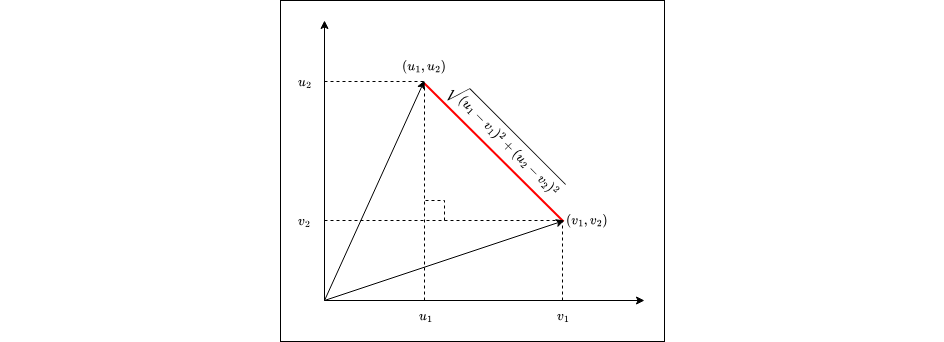

In [1]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

# Define two vectors
embedding1 = np.array([1.5, 2.0, 3.5])
embedding2 = np.array([4.0, 1.0, 2.5])

# Calculate Euclidean distance
euclidean_dist = euclidean_distances([embedding1], [embedding2])[0][0]
print("Euclidean distance:", euclidean_dist)

Euclidean distance: 2.8722813232690143


### 余先余弦相似度

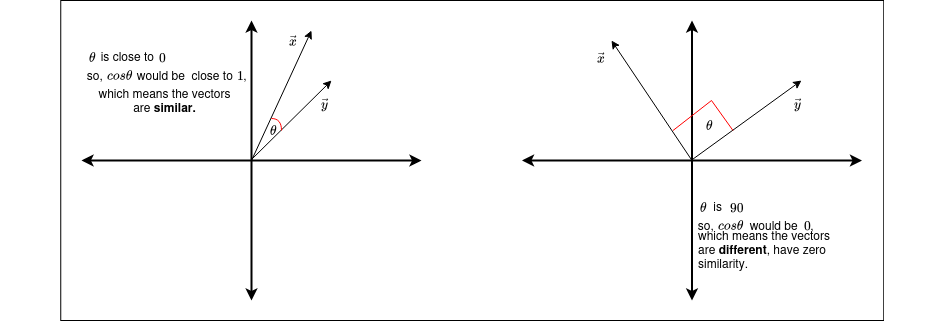

In [2]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Define two vectors
embedding1 = np.array([1.5, 2.0, 3.5])
embedding2 = np.array([4.0, 1.0, 2.5])

# Calculate cosine similarity
cosine_sim = cosine_similarity([embedding1], [embedding2])[0][0]
print("Cosine similarity:", cosine_sim)

Cosine similarity: 0.8076393462255516


### 点积

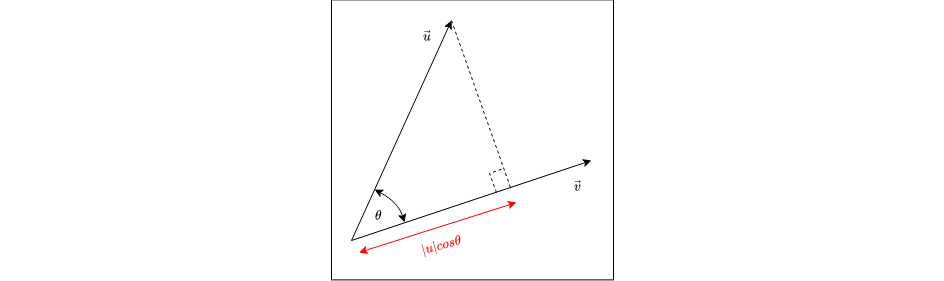

In [3]:
import numpy as np

# Define two vectors
embedding1 = np.array([1.5, 2.0, 3.5])
embedding2 = np.array([4.0, 1.0, 2.5])

# Calculate the dot product
dot_product = np.dot(embedding1, embedding2)
print("Dot product:", dot_product)

Dot product: 16.75


## 嵌入

### 单词嵌入

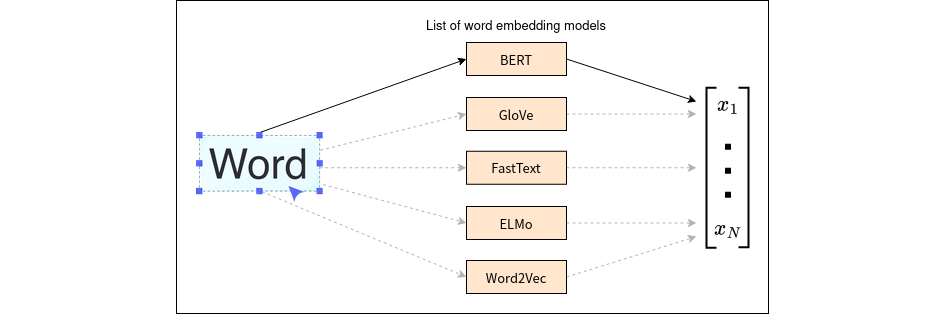

### 句子嵌入

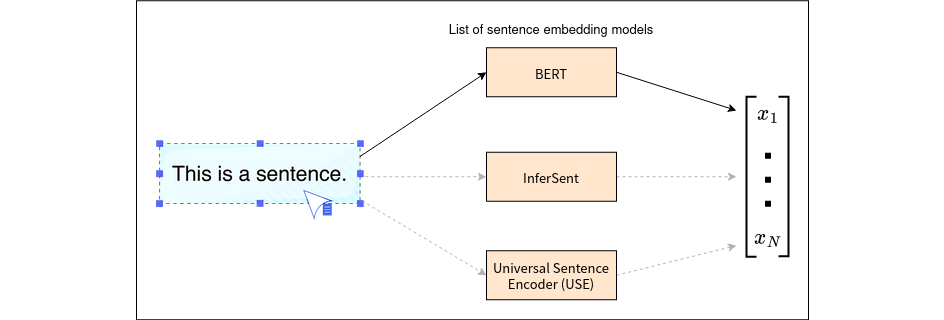

### 文档嵌入

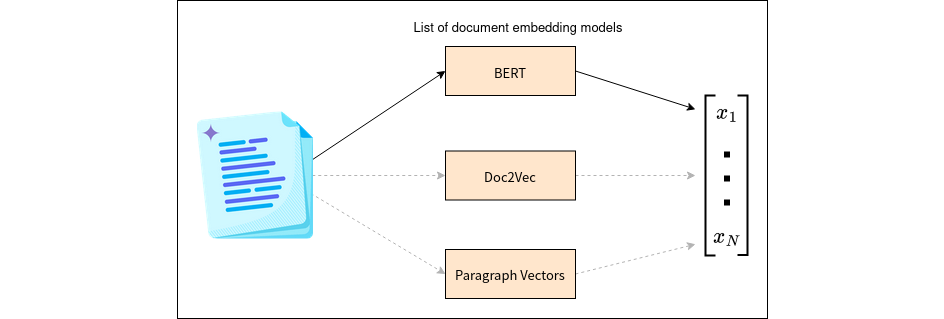

### 图像嵌入

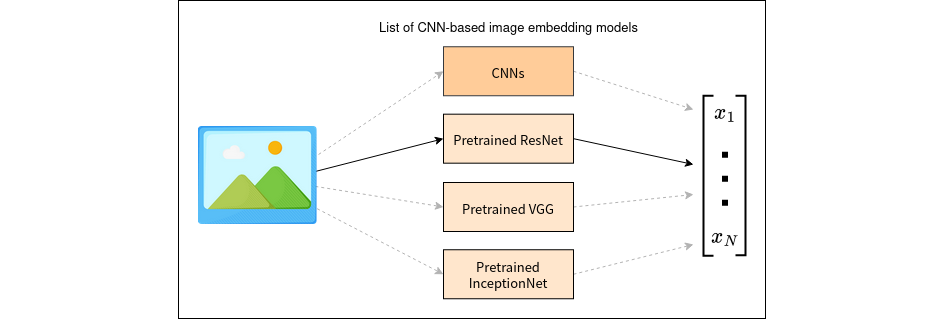

### 视频嵌入

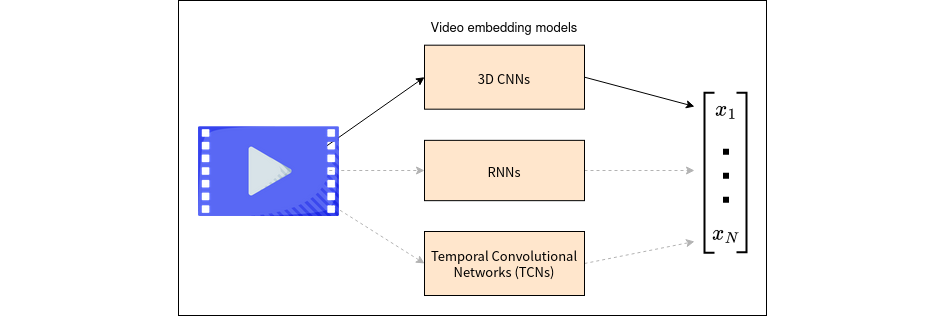

### 音频嵌入

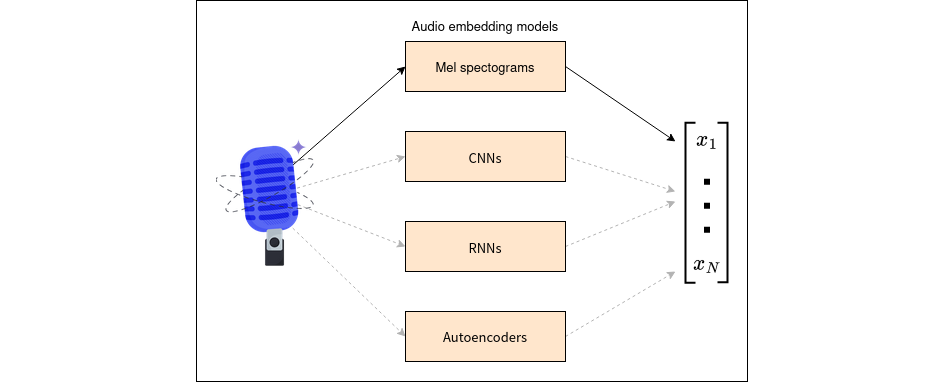

### 单模态 vs 多模态

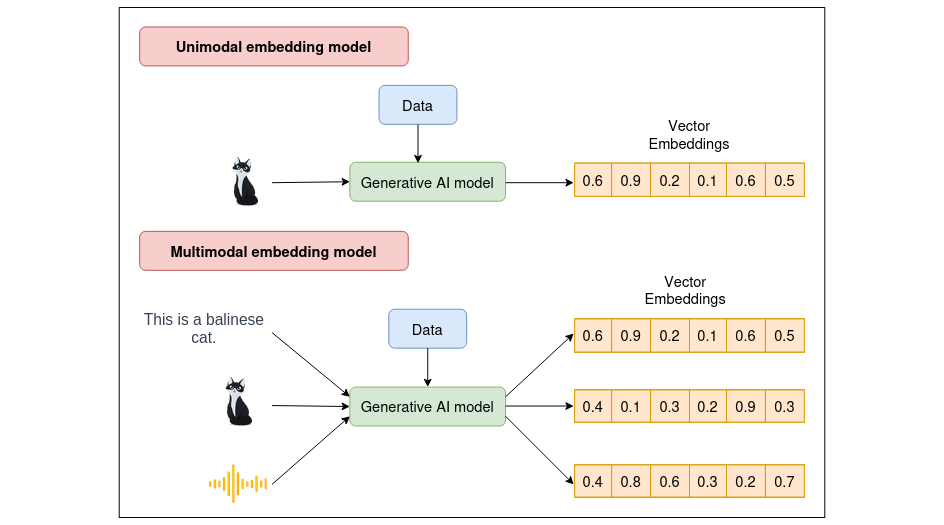

### 嵌入生成步骤

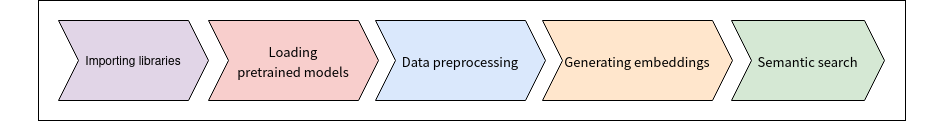

#### 使用BERT进行文本嵌入

In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
import warnings
warnings.filterwarnings('ignore')

# Load dataset from CSV file
df = pd.read_csv("/usr/local/datasetsDir/text-dataset/job_title_des.csv")

# Read only the first twenty job descriptions
df = df.head(20)

# Preprocess text data
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and token not in string.punctuation]
    return ' '.join(tokens)

df['processed_description'] = df['Job Description'].apply(preprocess)

# Load pretrained BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Function to generate BERT embedding for a text using [CLS] token
def generate_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
    cls_embedding = outputs.last_hidden_state[:, 0, :]  # Extract [CLS] token embedding
    return cls_embedding.numpy()

# Function for semantic search
def semantic_search(query, top_n=3):
    query_embedding = generate_embedding(query)
    similarities = []
    for idx, row in df.iterrows():
        desc_embedding = generate_embedding(row['processed_description'])
        similarity = cosine_similarity(query_embedding, desc_embedding)[0][0]
        similarities.append((row['Job Title'], similarity, row['Job Description']))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Example usage
query = "python developer with experience in web development"
results = semantic_search(query)
for title, similarity, description in results:
    print(f"Title: {title}, Similarity: {similarity:.2f}")

#### 图像嵌入

In [ ]:
import os
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Load the pretrained ResNet model
resnet_model = models.resnet18(pretrained=True)
# Remove the final fully connected layer
resnet_model = torch.nn.Sequential(*(list(resnet_model.children())[:-1]))
# Set the model to evaluation mode
resnet_model.eval()

# Preprocess image
def preprocess_image(image_path):
    image = Image.open(image_path)
    # Define transformations to be applied to the image
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    # Apply transformations
    image_tensor = preprocess(image)
    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)
    return image_tensor

# Function to generate image embeddings
def generate_image_embedding(image_path):
    # Preprocess image
    image_tensor = preprocess_image(image_path)
    # Forward pass through the model to obtain features
    with torch.no_grad():
        features = resnet_model(image_tensor)
    # Flatten the feature map
    embedding = features.squeeze().numpy()
    return embedding

# Function for semantic search
def semantic_search(query_embedding, image_folder, top_n=2):
    similarities = []
    for filename in os.listdir(image_folder):
        if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            image_path = os.path.join(image_folder, filename)
            # Generate embedding for the image
            image_embedding = generate_image_embedding(image_path)
            # Compute cosine similarity between query embedding and image embedding
            similarity = cosine_similarity([query_embedding], [image_embedding])[0][0]
            similarities.append((filename, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Test
query_image_folder = "/usr/local/datasetsDir/image-dataset/queries"  # Path to the query image
image_folder = "/usr/local/datasetsDir/image-dataset/data"  # Path to the folder containing images

for filename in os.listdir(query_image_folder):
  if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
    query_image_path = os.path.join(query_image_folder, filename)
    query_embedding = generate_image_embedding(query_image_path)
    print("Query Image: ")
    display(Image.open(query_image_path))
    results = semantic_search(query_embedding, image_folder)
    print("Top matching images: ")
    for filename, similarity in results:
      display(Image.open(os.path.join(image_folder, filename)))
      print(f"{filename}, (Similarity: {similarity:.4f})")
      print("----------------------------------------------")

#### 视频嵌入

In [ ]:
import warnings
import cv2
import torch
import torchvision.models.video as models
import os
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Video, clear_output
import warnings
warnings.filterwarnings('ignore')

# Suppress warnings
warnings.filterwarnings("ignore")

# Load the pretrained 3D CNN model
cnn_model = models.r3d_18(pretrained=True)

# Set the model to evaluation mode
cnn_model.eval()

# Preprocess video frames
def preprocess_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert frame to RGB
        frame = cv2.resize(frame, (224, 224))  # Resize frame to (224, 224) for compatibility with the model
        frames.append(frame)
    cap.release()
    video_frames = torch.tensor(frames, dtype=torch.float).permute(3, 0, 1, 2) / 255.0  # Normalize pixel values to [0, 1]
    video_frames = video_frames.unsqueeze(0)  # Add batch dimension
    return video_frames

# Function to generate video embedding
def generate_video_embedding(video_path):
    video_frames = preprocess_video(video_path)
    with torch.no_grad():
        output = cnn_model(video_frames)
    return output.squeeze().numpy()

# Function for semantic search
def semantic_search(query_embedding, video_folder, top_n=2):
    similarities = []
    for filename in os.listdir(video_folder):
        if filename.endswith('.mp4'):
            video_path = os.path.join(video_folder, filename)
            # Generate embedding for the video
            video_embedding = generate_video_embedding(video_path)
            # Compute cosine similarity between query embedding and video embedding
            similarity = cosine_similarity([query_embedding], [video_embedding])[0][0]
            similarities.append((filename, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Test
query_video_folder = "/usr/local/datasetsDir/video-dataset/queries"  # Path to the query video
video_folder = "/usr/local/datasetsDir/video-dataset/data"  # Path to the folder containing videos
for filename in os.listdir(query_video_folder):
  if filename.endswith('.mp4'):
    print("Query Video: ", filename)
    query_video_path = os.path.join(query_video_folder, filename)
    query_embedding = generate_video_embedding(query_video_path)
    display(Video(query_video_path, embed=True))
    results = semantic_search(query_embedding, video_folder)
    print("Top matching videos: ")
    for filename, similarity in results:
      print(f"{filename}, Similarity: {similarity:.2f}")
      display(Video(os.path.join(video_folder, filename), embed=True))

#### 音频嵌入

In [ ]:
import torch
import torchaudio
import os
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Audio
import warnings
warnings.filterwarnings('ignore')

# Set the sample rate to match the audio requirements
SAMPLE_RATE = 16000

# Function to convert AAC to WAV and save in a new folder
def convert_aac_to_wav(aac_file_path):
    wav_filename = os.path.basename(aac_file_path)[:-3] + 'wav'
    output_folder = "./wav_files"  # New folder to save WAV files
    os.makedirs(output_folder, exist_ok=True)
    output_wav_path = os.path.join(output_folder, wav_filename)
    import subprocess
    with open(os.devnull, 'w') as devnull:
        subprocess.run(['ffmpeg', '-y', '-i', aac_file_path, output_wav_path], stdout=devnull, stderr=devnull)
    return output_wav_path

# Function to generate audio embedding
def generate_audio_embedding(audio_path):
    # Our audio files are in the aac format. We need to convert them to wave format to load them with the torchaudio
    audio_path = convert_aac_to_wav(audio_path)

    # Load audio waveform
    waveform, sample_rate = torchaudio.load(audio_path)

    # Resample audio if necessary
    if sample_rate != SAMPLE_RATE:
        waveform = torchaudio.transforms.Resample(sample_rate, SAMPLE_RATE)(waveform)

    # Convert audio waveform to mono if necessary
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Convert audio waveform to mel spectrogram
    mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=SAMPLE_RATE)(waveform)

    # Normalize the mel spectrogram
    mel_spectrogram = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram)

    # Collapse the mel spectrogram to a 1-dimensional embedding
    embedding = mel_spectrogram.mean(dim=-1).squeeze()

    return embedding.numpy()

# Function for semantic search
def semantic_search(query_embedding, audio_folder, top_n=1):
    similarities = []
    for filename in os.listdir(audio_folder):
        if filename.endswith(('.wav', '.mp3', '.aac')):
            audio_path = os.path.join(audio_folder, filename)
            # Generate embedding for the audio
            audio_embedding = generate_audio_embedding(audio_path)
            # Compute cosine similarity between query embedding and audio embedding
            similarity = cosine_similarity([query_embedding], [audio_embedding])[0][0]
            similarities.append((filename, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Example usage
query_audio_folder = "/usr/local/datasetsDir/audio-dataset/queries"  # Path to the query audio
audio_folder = "/usr/local/datasetsDir/audio-dataset/data"  # Path to the folder containing audio files

for filename in os.listdir(query_audio_folder):
    if filename.endswith(('.wav', '.mp3', '.aac')):
        query_audio_path = os.path.join(query_audio_folder, filename)
        print("Query Audio: ", filename)
        display(Audio(filename=query_audio_path, autoplay=True))
        query_embedding = generate_audio_embedding(query_audio_path)
        results = semantic_search(query_embedding, audio_folder)
        for filename, similarity in results:
            print(f"Matching Audio: {filename}, Similarity: {similarity:.2f}")
            display(Audio(filename=os.path.join(audio_folder, filename), autoplay=True))


#### 多模态嵌入

##### CLIP

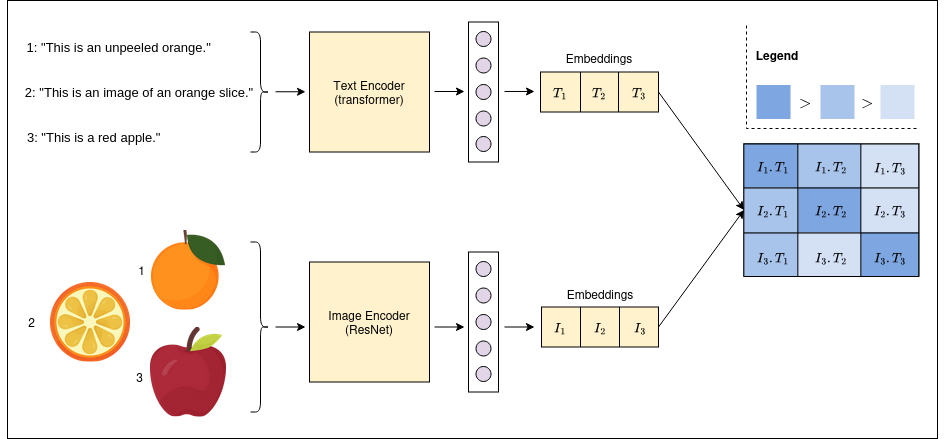

###### 生成嵌入

In [ ]:
import os
import pandas as pd
import clip
import torch
from PIL import Image

import warnings
warnings.filterwarnings('ignore')

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
model.eval()

# Path configurations
images_folder = '/usr/local/datasetsDir/images-and-descriptions/data/images'
csv_file = '/usr/local/datasetsDir/images-and-descriptions/data/image_descriptions.csv'

# Load the CSV file with image IDs and descriptions
df = pd.read_csv(csv_file)

# Prepare lists for image paths and descriptions
image_paths = []
descriptions = []

# Iterate through the CSV file to get image paths and corresponding descriptions
for _, row in df.iterrows():
    image_id = str(row[0])  # Ensure that the ID is a string for matching
    description = row[1]
    # Find the image file corresponding to the image_id
    for file_name in os.listdir(images_folder):
        if file_name.startswith(f"{image_id}_") and file_name.endswith('.png'):
            image_path = os.path.join(images_folder, file_name)
            image_paths.append(image_path)
            descriptions.append(description)
            break

# Function to preprocess images and text descriptions
def preprocess_data(image_paths, descriptions):
    images = [preprocess(Image.open(image_path)) for image_path in image_paths]
    text_inputs = [clip.tokenize(description, truncate=True) for description in descriptions]
    return torch.stack(images), torch.cat(text_inputs)

# Preprocess images and descriptions
images, text_inputs = preprocess_data(image_paths, descriptions)

# Generate embeddings
with torch.no_grad():
    image_features = model.encode_image(images)
    text_features = model.encode_text(text_inputs)
# Normalize the features
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)

# Print embeddings
print("Image embeddings: ", image_features)
print("Text embeddings: ", text_features)

# Save the embeddings and metadata for later use
torch.save({
    'image_features': image_features,
    'text_features': text_features,
    'image_paths': image_paths,
    'descriptions': descriptions
}, '/usr/local/datasetsDir/images-and-descriptions/embeddings.pt')

print("Embeddings generated and saved successfully.")

###### 通过文本搜索图片

In [ ]:
import clip
import torch
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
model.eval()

# Load the embeddings and metadata
embeddings = torch.load('/usr/local/datasetsDir/images-and-descriptions/embeddings.pt')
image_features = embeddings['image_features']
text_features = embeddings['text_features']
image_paths = embeddings['image_paths']
descriptions = embeddings['descriptions']

# Function to search images and descriptions by text
def search_by_text(query, image_features, text_features, image_paths, descriptions):
    text_input = clip.tokenize([query])
    with torch.no_grad():
        query_feature = model.encode_text(text_input)
    query_feature /= query_feature.norm(dim=-1, keepdim=True)

    similarities = cosine_similarity(query_feature, image_features)

    top_match_idxs = top_match_idxs = similarities[0].argsort()[-5:][::-1]
    results = [(image_paths[idx], descriptions[idx], similarities[0][idx].item()) for idx in top_match_idxs]

    return results

# Test
text_query = "Fruits containing vitamic C nutrient"
print("Query: ", text_query)
results = search_by_text(text_query, image_features, text_features, image_paths, descriptions)
for idx, (image_path, description, similarity) in enumerate(results):
    print(f"Match {idx + 1}:")
    display(Image.open(image_path))
    print(f"Description: {description} (Similarity: {similarity:.4f})")
    print("------------")

###### 通过图片搜索文本

In [ ]:
import clip
import torch
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
model.eval()

# Load the embeddings and metadata
embeddings = torch.load('/usr/local/datasetsDir/images-and-descriptions/embeddings.pt')
image_features = embeddings['image_features']
text_features = embeddings['text_features']
image_paths = embeddings['image_paths']
descriptions = embeddings['descriptions']

# Function to search images and descriptions by image
def search_by_image(query_image_path, image_features, text_features, image_paths, descriptions):
    image_input = preprocess(Image.open(query_image_path)).unsqueeze(0)
    with torch.no_grad():
        query_feature = model.encode_image(image_input)
    query_feature /= query_feature.norm(dim=-1, keepdim=True)

    similarities = cosine_similarity(query_feature, text_features)

    top_match_idxs = top_match_idxs = similarities[0].argsort()[-5:][::-1]
    results = [(image_paths[idx], descriptions[idx], similarities[0][idx].item()) for idx in top_match_idxs]

    return results

# Test
query_image_path = '/usr/local/datasetsDir/images-and-descriptions/queries/girlwithorangesliceoneyes.jpg'
print("Query Image:")
display(Image.open(query_image_path))
print("Finding similar results, please wait...")
results = search_by_image(query_image_path, image_features, text_features, image_paths, descriptions)
for idx, (image_path, description, similarity) in enumerate(results):
    print(f"Match {idx + 1}:")
    display(Image.open(image_path))
    print(f"Description: {description} (Similarity: {similarity:.4f})")
    print("------------")

##### 微调CLIP

In [ ]:
import torch.optim as optim
import os
import pandas as pd
import clip
import torch
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = "cuda:0" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32",device=device,jit=False)
if device == "cpu":
  model.float()
else :
  clip.model.convert_weights(model)

# Function to preprocess data
def preprocess_data(image_paths, texts):
    images = [preprocess(Image.open(image_path)) for image_path in image_paths]
    text_inputs = [clip.tokenize(text, context_length=77, truncate=True) for text in texts]
    return torch.stack(images), torch.cat(text_inputs)

# Load the CSV file with image IDs and descriptions
csv_file = '/usr/local/datasetsDir/images-and-descriptions/data/image_descriptions.csv'
df = pd.read_csv(csv_file)
# Folder containing the images
images_folder = '/usr/local/datasetsDir/images-and-descriptions/data/images'

# Prepare lists for image paths and descriptions
image_paths = []
texts = []
# Iterate through the CSV file to get image paths and corresponding descriptions
for _, row in df.iterrows():
    image_id = str(row[0])  # Ensure the ID is a string for matching
    description = row[1]
    # Find the image file corresponding to the image_id
    for file_name in os.listdir(images_folder):
        if file_name.startswith(f"{image_id}_") and file_name.endswith('.png'):
            image_path = os.path.join(images_folder, file_name)
            image_paths.append(image_path)
            texts.append(description)
            break

# Preprocess images and text descriptions
images, text_inputs = preprocess_data(image_paths, texts)

def convert_models_to_fp32(model):
    for p in model.parameters():
        p.data = p.data.float()
        p.grad.data = p.grad.data.float()

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-5)
num_epochs=30
# Training loop
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    images= images.to(device)
    text_inputs = text_inputs.to(device)

    logits_per_image, logits_per_text = model(images, text_inputs)
    labels = torch.arange(len(images),dtype=torch.long,device=device)

    loss = (torch.nn.functional.cross_entropy(logits_per_image, labels) + torch.nn.functional.cross_entropy(logits_per_text, labels)) / 2
    loss.backward()
    if device == "cpu":
         optimizer.step()
    else :
        convert_models_to_fp32(model)
        optimizer.step()
        clip.model.convert_weights(model)

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Save the fine-tuned model
model_save_path = '/usr/local/datasetsDir/images-and-descriptions/fine_tuned_clip_model_30_epochs.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': num_epochs,
    'loss': loss.item(),
}, model_save_path)

print("Fine-tuned model saved successfully.")

###### Generate embeddings with fine-tuned CLIP model

In [ ]:
import os
import pandas as pd
import clip
import torch
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
# Load the saved model state
model_save_path = '/usr/local/datasetsDir/images-and-descriptions/fine_tuned_clip_model_30_epochs.pth'
checkpoint = torch.load(model_save_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Path configurations
images_folder = '/usr/local/datasetsDir/images-and-descriptions/data/images'
csv_file = '/usr/local/datasetsDir/images-and-descriptions/data/image_descriptions.csv'

# Load the CSV file with image IDs and descriptions
df = pd.read_csv(csv_file)

# Prepare lists for image paths and descriptions
image_paths = []
descriptions = []

# Iterate through the CSV file to get image paths and corresponding descriptions
for _, row in df.iterrows():
    image_id = str(row[0])  # Ensure the ID is a string for matching
    description = row[1]
    # Find the image file corresponding to the image_id
    for file_name in os.listdir(images_folder):
        if file_name.startswith(f"{image_id}_") and file_name.endswith('.png'):
            image_path = os.path.join(images_folder, file_name)
            image_paths.append(image_path)
            descriptions.append(description)
            break
context_length=77
# Function to preprocess images and text descriptions
def preprocess_data(image_paths, descriptions):
    images = [preprocess(Image.open(image_path)) for image_path in image_paths]
    text_inputs = [clip.tokenize(description, context_length=77, truncate=True) for description in descriptions]
    return torch.stack(images), torch.cat(text_inputs)

# Preprocess images and descriptions
images, text_inputs = preprocess_data(image_paths, descriptions)

# Generate embeddings
with torch.no_grad():
    image_features = model.encode_image(images)
    text_features = model.encode_text(text_inputs)
# Normalize the features
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
print("Image embeddings: ", image_features)
print("Text embeddings: ", text_features)

# Save the embeddings and metadata for later use
torch.save({
    'image_features': image_features,
    'text_features': text_features,
    'image_paths': image_paths,
    'descriptions': descriptions
}, '/usr/local/datasetsDir/images-and-descriptions/embeddingswithfinetunedmodel_temp.pt')

print("Embeddings generated and saved successfully.")

###### Search by text using embeddings generated with fine-tuned CLIP model

In [ ]:
import os
import pandas as pd
import clip
import torch
from PIL import Image
from IPython.display import display
import ipywidgets as widgets
from IPython.display import clear_output

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
model.eval()

# Load the embeddings and metadata
embeddings = torch.load('/usr/local/datasetsDir/images-and-descriptions/embeddingswithfinetunedmodel.pt')
image_features = embeddings['image_features']
text_features = embeddings['text_features']
image_paths = embeddings['image_paths']
descriptions = embeddings['descriptions']

# Normalize the features (if not already normalized)
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)

# Function to search images and descriptions by text
def search_by_text(query, image_features, text_features, image_paths, descriptions):
    text_input = clip.tokenize([query])
    with torch.no_grad():
        query_feature = model.encode_text(text_input).float()
    query_feature /= query_feature.norm(dim=-1, keepdim=True)

    similarities = (100.0 * query_feature @ image_features.T).softmax(dim=-1)
    top_match_idxs = similarities[0].topk(5).indices.tolist()
    results = [(image_paths[idx], descriptions[idx], similarities[0][idx].item()) for idx in top_match_idxs]

    return results

# Test
text_query = "Fruits containing vitamic C nutrient"
print("Query: ", text_query)
results = search_by_text(text_query, image_features, text_features, image_paths, descriptions)
for idx, (image_path, description, similarity) in enumerate(results):
    print(f"Match {idx + 1}:")
    display(Image.open(image_path))
    print(f"Description: {description} (Similarity: {similarity:.4f})")
    print("------------")

###### Search by image using embeddings generated with fine-tuned CLIP model

In [ ]:
import os
import pandas as pd
import clip
import torch
from PIL import Image
from IPython.display import display
import ipywidgets as widgets
from IPython.display import clear_output

# Load the model and preprocess function from CLIP
model, preprocess = clip.load("ViT-B/32")
model.eval()

# Load the embeddings and metadata
embeddings = torch.load('/usr/local/datasetsDir/images-and-descriptions/embeddingswithfinetunedmodel.pt')
image_features = embeddings['image_features']
text_features = embeddings['text_features']
image_paths = embeddings['image_paths']
descriptions = embeddings['descriptions']

# Normalize the features (if not already normalized)
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)

# Function to search images and descriptions by image
def search_by_image(uploaded_image_path, image_features, text_features, image_paths, descriptions):
    image_input = preprocess(Image.open(uploaded_image_path)).unsqueeze(0)
    with torch.no_grad():
        query_feature = model.encode_image(image_input).float()
    query_feature /= query_feature.norm(dim=-1, keepdim=True)

    similarities = (100.0 * query_feature @ text_features.T).softmax(dim=-1)
    top_match_idxs = similarities[0].topk(5).indices.tolist()
    results = [(image_paths[idx], descriptions[idx], similarities[0][idx].item()) for idx in top_match_idxs]

    return results

# Test
query_image_path = '/usr/local/datasetsDir/images-and-descriptions/queries/girlwithorangesliceoneyes.jpg'
print("Query Image:")
display(Image.open(query_image_path))
print("Finding similar results, please wait...")
results = search_by_image(query_image_path, image_features, text_features, image_paths, descriptions)
for idx, (image_path, description, similarity) in enumerate(results):
    print(f"Match {idx + 1}:")
    display(Image.open(image_path))
    print(f"Description: {description} (Similarity: {similarity:.4f})")
    print("------------")

### Chromadb

In [ ]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
from IPython.display import display, Image as IPImage

# Configure embedding model to be used by the database to generate embedding
model_name = "ViT-B-32"
embedding_function = OpenCLIPEmbeddingFunction(model_name=model_name)

# Loads images from image URI's given to the database
data_loader = ImageLoader()

# Create chroma client
client = chromadb.Client()
collection_name="multimodal_embeddings_collection"

# Create chroma collection
collection = client.create_collection(
    name=collection_name,
    embedding_function=embedding_function,
    metadata={"hnsw:space": "cosine"},
    data_loader=data_loader)

# ****Prepare dataset to be added to the collection****
# Load the CSV file with image IDs and descriptions
csv_file = '/usr/local/datasetsDir/images-and-descriptions/data/image_descriptions.csv'
df = pd.read_csv(csv_file)
# Folder containing the images
images_folder = '/usr/local/datasetsDir/images-and-descriptions/data/images'
# Prepare lists for image paths, image ids, descriptions, and description ids
image_paths = []
image_Ids = []
descriptions = []
description_Ids=[]
# Iterate through the CSV file to get image paths and corresponding descriptions
for _, row in df.iterrows():
    des_id = str(row[0])  # Ensure the ID is a string for matching
    description_Ids.append(des_id)
    description = str(row[1])
    # Find the image file corresponding to the image_id
    for file_name in os.listdir(images_folder):
        if file_name.startswith(f"{des_id}_") and file_name.endswith('.png'):
            image_path = os.path.join(images_folder, file_name)
            image_Ids.append(file_name)
            image_paths.append(image_path)
            descriptions.append(description)
            break

# Add images and descriptions to the collection
for img_id, img_path, desc_id, desc in zip(image_Ids, image_paths, description_Ids, descriptions):
    collection.add(
        ids=[img_id],
        uris=[img_path],
        metadatas=[{"image_uri": img_path, "description": desc}]
    )
    collection.add(
        ids=[desc_id],
        documents=[desc],
        metadatas=[{"image_uri": img_path, "description": desc}]
    )

# Query by text
query_text= "vitamic C fruits"
text_query_results = collection.query(
    query_texts=[query_text],
    n_results=5
)
# Display text query results
print("Text query: ", query_text)
print("Text query results array returned by the database: ", text_query_results)
print("*********** Visualizing the results ************")
for metadata, distance in zip(text_query_results['metadatas'][0], text_query_results['distances'][0]):
    print(f"Description: {metadata['description']}")
    print(f"Distance: {distance:.4f}")
    display(IPImage(filename=metadata['image_uri']))


# Query by image
query_images=[]
query_image_path = '/usr/local/datasetsDir/images-and-descriptions/queries/girlwithorangesliceoneyes.jpg'
query_images.append(query_image_path)
image_query_results = collection.query(
    query_uris=query_images,
    n_results=5
)
print("Image query: ")
display(IPImage(filename=query_image_path))
print("Image query results array returned by the database: ", image_query_results)
print("*********** Visualizing the results ************")
for metadata, distance in zip(image_query_results['metadatas'][0], image_query_results['distances'][0]):
    print(f"Description: {metadata['description']}")
    print(f"Distance: {distance:.4f}")
    display(IPImage(filename=metadata['image_uri']))

# Delete the collection
client.delete_collection(name=collection_name)

## Demo - Music Recommendation System

In [ ]:
import pandas as pd
from transformers import BertTokenizer
from transformers import BertModel
import torch
import os
import numpy as np

# Define special tokens for numeric attributes
SPECIAL_TOKENS = {
        '[DANCEABILITY]': 'danceability',
        '[SPEECHINESS]': 'speechiness',
        '[ENERGY]': 'energy',
        '[LOUDNESS]': 'loudness',
        '[ACOUSTICNESS]': 'acousticness',
        '[INSTRUMENTALNESS]': 'instrumentalness',
        '[LIVENESS]': 'liveness',
        '[VALENCE]': 'valence',
        '[TEMPO]': 'tempo'
    }

# Tokenize using custom special tokens
def tokenize_with_special_tokens(text):
    for token, attribute in SPECIAL_TOKENS.items():
        text = text.replace(attribute, token)
    return text

def generateMetadataEmbeddings(metadata_df):
    # Extract relevant numeric attributes
    metadata_df['textual_description'] = metadata_df.apply(
        lambda row: f"The song {row['song_name']} has a danceability of {row['danceability']}, "
                    f"energy of {row['energy']}, "
                    f"loudness of {row['loudness']}, "
                    f"speechiness of {row['speechiness']}, "
                    f"acousticness of {row['acousticness']}, "
                    f"instrumentalness of {row['instrumentalness']}, "
                    f"liveness of {row['liveness']}, "
                    f"valence of {row['valence']}, "
                    f"tempo of {row['tempo']}",
        axis=1
    )
    # Save the updated DataFrame back to the CSV file
    metadata_df.to_csv(metadata_file_path, index=False)

    # Initialize BERT tokenizer
    bert_model_name = 'bert-base-uncased'
    tokenizer = BertTokenizer.from_pretrained(bert_model_name)    

    # Apply tokenization to create input for BERT
    metadata_df['textual_description_with_Special_Tokens'] = metadata_df['textual_description'].apply(tokenize_with_special_tokens)

    # Tokenize using BERT tokenizer
    encoded_inputs = tokenizer(metadata_df['textual_description_with_Special_Tokens'].tolist(), padding=True, truncation=True, return_tensors='pt')
    for input_id in encoded_inputs['input_ids']:
    bert_tokenized_text = tokenizer.convert_ids_to_tokens(input_id)

    # Load BERT model
    bert_model = BertModel.from_pretrained(bert_model_name)

    # Forward pass through BERT
    with torch.no_grad():
        outputs = bert_model(**encoded_inputs)

    # Extract embeddings from BERT output
    last_hidden_states = outputs.last_hidden_state
    metadata_embeddings = last_hidden_states[:, 0, :].numpy()  # Use CLS token for sentence-level embedding
    return metadata_embeddings

# Function to get song_name, Genre, and textual description for a specific songID
def getSongDetails(song_id):
    if song_id in metadata_df['song_ID'].values:
        # Filter the DataFrame to get the row matching the song_id
        song_row = metadata_df.loc[metadata_df['song_ID'] == song_id]

        # Extract song_name, Genre, and textual_description
        song_name = song_row['song_name'].values[0]
        genre = song_row['genre'].values[0]
        textual_description = song_row['textual_description'].values[0]

        return song_name, genre, textual_description
    else:
        return None, None, f"No song found with songID {song_id}"

In [ ]:
from songmetadata import generateMetadataEmbeddings, getSongDetails
import pandas as pd
import os

# Preparing data we want to add to the collection
ids_list = []
doc_list = []
embeddings_list = []
metadata_list = []

metadata_CSV_file_path="/usr/local/musicRecommendationSystemDir/metadata_songs.csv"
metadata_df = pd.read_csv(metadata_file_path)

song_IDs_list = metadata_df['song_ID']
metadata_embeddings = generateMetadataEmbeddings(metadata_df)

for i in range(len(song_IDs_list)):
    songID = song_IDs_list[i]
    ids_list.append(songID)

    embedding = metadata_embeddings[i]
    embeddings_list.append(embedding.tolist())

    song_name, genre, description = getSongDetails(songID)
    doc_list.append(description)

    metadata = {}
    metadata ["song_name"] = song_name
    metadata ["genre"] = genre
    metadata ["URI"] = "/usr/local/musicRecommendationSystemDir/audio-files/" + songID + ".wav"
    print(metadata)
    metadata_list.append(metadata)

# Adding to the collection song IDs, textual descriptions (docs), embeddings for each doc, and metadata, including song name, genre, and URI
metadata_collection  = client.get_collection(name=metadata_collection_name)
metadata_collection.add(
    documents=doc_list,
    embeddings=embeddings_list,
    metadatas=metadata_list,
    ids=ids_list
)